In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import rasterio
import utils
import get_table
import importlib
from osgeo import gdal
from rasterio import features


C:\Users\rp1y21\AppData\Local\Temp\ipykernel_12204\2164908369.py:3: DeprecationWarning: GeoPandas is set to use PyGEOS over Shapely. PyGEOS support is deprecatedand will be removed in GeoPandas 1.0, released in the Q1 of 2024. Please migrate to Shapely 2.0 (https://geopandas.org/en/stable/docs/user_guide/pygeos_to_shapely.html).
  import geopandas as gpd


In [13]:
importlib.reload(get_table)
importlib.reload(get_table.utils)

paths = ['output/abw.vrt']
res = get_table.extract('output/geoBoundaries-ABW-ADM0.geojson', 
                        paths, names=['p1'], weighted=True,
                        edge=True, rad=2, return_array=True)
res['df']

,id,p1,count
0,1,3538.999749,236


<Axes: >

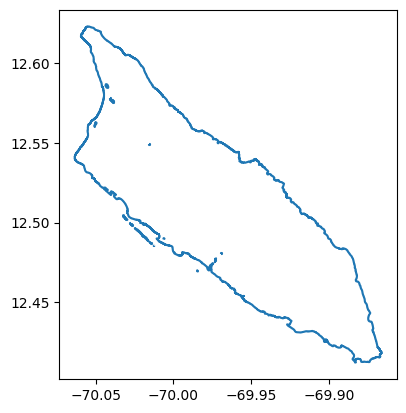

In [2]:
adm0 = gpd.read_file('output/geoBoundaries-ABW-ADM0.geojson')
adm0.boundary.plot()

In [3]:
paths = ['output/abw_m_10_2020_CN_1km_R2025A_UA_v1.tif']
vrt = gdal.BuildVRT('output/abw.vrt', paths)
vrt = None

In [143]:
importlib.reload(get_table)
importlib.reload(get_table.utils)

#DATA EXTRACTION
path = 'output/geoBoundaries-ABW-ADM0.geojson'
#path = 'output/abw_test_point.gpkg'
pts = gpd.read_file(path)
res_w,outpt = get_table.extract(path,
                                'output/abw.vrt', 
                                resolution='1km', 
                                return_gdf=True, 
                                return_arr=True,
                                edge=True,
                                explode=False, rad=4, weighted=True, p=1)

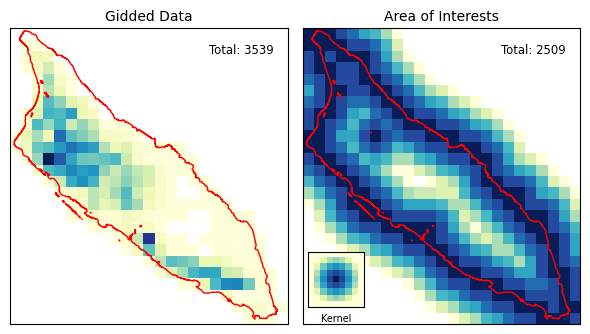

In [144]:
#VISUALISATION
fig,ax = plt.subplots(1, 2, figsize=(6,4), dpi=100)
title = ['Gidded Data', 'Area of Interests']
ay = ax[1].inset_axes([0.02,0.05,0.2,0.2])

pop = outpt['data'].copy()
if outpt['weight'] is None:
    wgt = outpt['mask'].copy().astype(float)
else:
    wgt = outpt['weight'].copy()
krn = outpt['kernel'].copy()
pop[pop < 0] = np.nan
wgt[wgt <= 0] = np.nan
#krn[krn <= 0] = np.nan
bds = outpt['bounds']
ext = [bds[0], bds[2], bds[1], bds[3]]

total = [np.nansum(pop), res_w['pop'].sum()]

cmap = 'YlGnBu'
ax[0].imshow(pop, extent=ext, cmap=cmap)
ax[1].imshow(wgt, extent=ext, cmap=cmap)
ay.imshow(krn, cmap=cmap)
ay.set_xticks([])
ay.set_yticks([])
ay.set_xlabel('Kernel', fontsize='x-small')

for i in [0,1]:
    adm0.boundary.plot(ax=ax[i], color='r', lw=1)
    #pts.plot(ax=ax[i], color='r', markersize=20)
    txt = f'Total: {total[i]:.0f}'
    ax[i].text(0.95, 0.95, txt, transform=ax[i].transAxes, 
               fontsize='small', ha='right', va='top')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title(title[i], fontsize='medium')
    
plt.tight_layout()
plt.savefig('fig/aoi_line_weighted.png')
plt.show()